### 0. Imports and Paths

In [2]:
from pathlib import Path
import cv2
import numpy as np
from collections import Counter
from tqdm import tqdm
import albumentations as A
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
DATA_ROOT = Path("../data_for_yolo")

IMG_DIR = DATA_ROOT / "images/train"
LBL_DIR = DATA_ROOT / "labels/train"

OUT_IMG = DATA_ROOT / "train_bal/images"
OUT_LBL = DATA_ROOT / "train_bal/labels"

OUT_IMG.mkdir(parents=True, exist_ok=True)
OUT_LBL.mkdir(parents=True, exist_ok=True)

### 1. Load YOLO Labels

In [4]:
def read_labels(path):
    classes, boxes = [], []
    with open(path, "r") as f:
        for line in f:
            c, x, y, w, h = map(float, line.strip().split())
            classes.append(int(c))
            boxes.append([x, y, w, h])
    return classes, boxes

### 2. Dataset Statistics

In [5]:
image_labels = {}
class_counts = Counter()

for lf in LBL_DIR.glob("*.txt"):
    classes, _ = read_labels(lf)
    image_labels[lf.stem] = classes
    class_counts.update(classes)

print("Class distribution:", class_counts)

Class distribution: Counter({11: 11065, 0: 9667, 12: 8309, 3: 6188, 1: 5360, 7: 3294, 14: 3138, 9: 1958, 8: 1366, 10: 689, 6: 535, 5: 444, 16: 368, 2: 239, 15: 167, 13: 100, 4: 97})


### 3. Oversampling Logic

In [6]:
total = sum(class_counts.values())

class_weight = {
    c: total / (len(class_counts) * v)
    for c, v in class_counts.items()
}

def image_score(classes):
    return sum(class_weight[c] for c in classes)

TOTAL_MULTIPLIER = 1.5     # dataset grows ~1.5x
MAX_AUG_PER_IMAGE = 3      # hard cap

all_stems = list(image_labels.keys())

scores = np.array([image_score(image_labels[s]) for s in all_stems])
scores = scores / scores.sum()

target_total = int(len(all_stems) * TOTAL_MULTIPLIER)

image_aug_count = {}
for stem, score in zip(all_stems, scores):
    n_aug = int(np.log1p(score * target_total))
    n_aug = min(MAX_AUG_PER_IMAGE, n_aug)
    image_aug_count[stem] = n_aug

### 4. Albumentations

In [120]:
transform = A.Compose(
    [
        A.HorizontalFlip(p=0.5),

        A.RandomBrightnessContrast(p=0.3),
        A.HueSaturationValue(p=0.2),

        A.ShiftScaleRotate(
            shift_limit=0.0,   # ❌ no translation
            scale_limit=0.2,
            rotate_limit=15,
            p=0.7,
            border_mode=cv2.BORDER_CONSTANT,
            value=0
        ),

        A.GaussNoise(p=0.2),
        A.MotionBlur(p=0.2),
    ],
    bbox_params=A.BboxParams(
        format="yolo",
        label_fields=["class_labels"],
        min_visibility=0.2,
        check_each_transform=False
    ),
)

### 5. Helpers

In [121]:
def load_image(path):
    img = cv2.imread(str(path))
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

In [122]:
def augment(image, boxes, classes):
    try:
        out = transform(
            image=image,
            bboxes=boxes,
            class_labels=classes
        )
        if len(out["bboxes"]) == 0:
            return None, None, None
        return out["image"], out["bboxes"], out["class_labels"]
    except Exception:
        return None, None, None

In [123]:
def save(img, boxes, classes, img_path, lbl_path):
    cv2.imwrite(str(img_path), cv2.cvtColor(img, cv2.COLOR_RGB2BGR))
    with open(lbl_path, "w") as f:
        for c, (x, y, w, h) in zip(classes, boxes):
            f.write(f"{c} {x} {y} {w} {h}\n")

### 6. Build Balanced Dataset

In [124]:
for stem in tqdm(all_stems):

    img_path = None
    for ext in [".jpg", ".png", ".jpeg"]:
        p = IMG_DIR / f"{stem}{ext}"
        if p.exists():
            img_path = p
            break

    lbl_path = LBL_DIR / f"{stem}.txt"
    if img_path is None or not lbl_path.exists():
        continue

    image = load_image(img_path)
    classes, boxes = read_labels(lbl_path)

    # Save original (no data loss)
    save(image, boxes, classes, OUT_IMG / img_path.name, OUT_LBL / lbl_path.name)

    # Add controlled augmentations
    for i in range(image_aug_count[stem]):
        aug_img, aug_boxes, aug_classes = augment(image, boxes, classes)
        if aug_img is None:
            continue

        save(aug_img, aug_boxes, aug_classes, OUT_IMG / f"{stem}_aug{i}.jpg", OUT_LBL / f"{stem}_aug{i}.txt")

100%|██████████| 5669/5669 [1:58:07<00:00,  1.25s/it]     


### 7. Visualizing Results

In [127]:
DATA_ROOT = Path("../data_for_yolo")

OLD_LBL = DATA_ROOT / "labels/train"
NEW_LBL = DATA_ROOT / "train_bal/labels"

def count_yolo_instances(label_dir):
    counts = Counter()
    for lf in label_dir.glob("*.txt"):
        with open(lf) as f:
            for line in f:
                cls = int(line.split()[0])
                counts[cls] += 1
    return counts

In [128]:
old_counts = count_yolo_instances(OLD_LBL)
new_counts = count_yolo_instances(NEW_LBL)

In [129]:
# Class names (same as YAML)
class_names = {
    0: "person",
    1: "ear",
    2: "ear-mufs",
    3: "face",
    4: "face-guard",
    5: "face-mask-medical",
    6: "foot",
    7: "tools",
    8: "glasses",
    9: "gloves",
    10: "helmet",
    11: "hands",
    12: "head",
    13: "medical-suit",
    14: "shoes",
    15: "safety-suit",
    16: "safety-vest",
}

classes = sorted(class_names.keys())

df = pd.DataFrame({
    "class_id": classes,
    "class_name": [class_names[c] for c in classes],
    "before": [old_counts.get(c, 0) for c in classes],
    "after":  [new_counts.get(c, 0) for c in classes],
})

df["increase_factor"] = (df["after"] / df["before"]).round(2)

df

,class_id,class_name,before,after,increase_factor
0,0,person,9667,14143,1.46
1,1,ear,5360,7421,1.38
2,2,ear-mufs,239,575,2.41
3,3,face,6188,8486,1.37
4,4,face-guard,97,253,2.61
5,5,face-mask-medical,444,972,2.19
6,6,foot,535,1158,2.16
7,7,tools,3294,5272,1.60
8,8,glasses,1366,2088,1.53
9,9,gloves,1958,3471,1.77


In [132]:
# Sort by original (before) distribution, descending
df_sorted = df.sort_values(by="before", ascending=False).reset_index(drop=True)

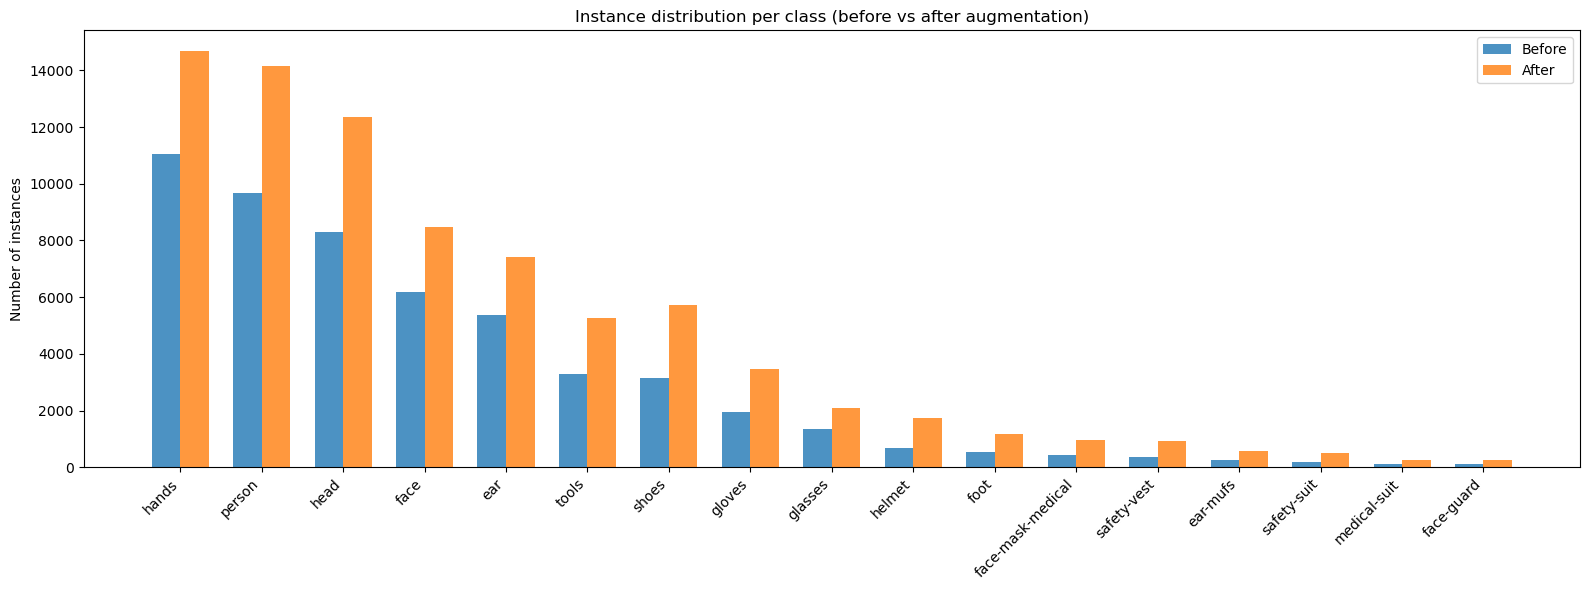

In [133]:
x = np.arange(len(df_sorted))
width = 0.35

plt.figure(figsize=(16, 6))

plt.bar(x - width/2, df_sorted["before"], width, label="Before", alpha=0.8)
plt.bar(x + width/2, df_sorted["after"],  width, label="After",  alpha=0.8)

plt.xticks(x, df_sorted["class_name"], rotation=45, ha="right")
plt.ylabel("Number of instances")
plt.title("Instance distribution per class (before vs after augmentation)")
plt.legend()

plt.tight_layout()
plt.show()